In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Define the path to your data (Goes UP from notebooks, then INTO data)
file_path = os.path.join('..', 'data', 'ethiopia.csv')

# Load and prepare the date index
df = pd.read_csv(file_path)
df['Date'] = pd.to_datetime(df['YEAR'].astype(str) + df['DOY'].astype(str), format='%Y%j')
df.set_index('Date', inplace=True)

# Preview the data
df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
Date,,,,,,,,,,,,
2015-01-01,2015,1,11.73,22.75,3.44,19.31,0.0,41.79,2.73,5.07,77.13,4.00
2015-01-02,2015,2,12.30,24.01,4.09,19.92,0.0,33.29,2.39,4.19,77.14,3.35
2015-01-03,2015,3,12.49,24.17,3.97,20.20,0.0,33.83,1.77,2.76,77.11,3.43
2015-01-04,2015,4,14.08,23.78,6.90,16.88,0.0,38.84,0.87,1.28,77.07,4.60
2015-01-05,2015,5,14.06,23.15,7.32,15.83,0.0,47.07,1.34,2.14,77.01,5.58


In [6]:
# Check for missing values
print("Missing Values Check:")
print(df.isnull().sum())

# Statistical Summary
print("\nStatistical Summary:")
display(df.describe())

Missing Values Check:
YEAR           0
DOY            0
T2M            0
T2M_MAX        0
T2M_MIN        0
T2M_RANGE      0
PRECTOTCORR    0
RH2M           0
WS2M           0
WS2M_MAX       0
PS             0
QV2M           0
dtype: int64

Statistical Summary:


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
count,4108.000000,4108.000000,4108.00000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000
mean,2020.131451,180.121227,16.06850,23.199175,10.227544,12.971631,3.633795,68.408588,1.979998,3.575246,77.037529,9.697724
std,3.248907,106.294767,1.89805,2.751471,2.607256,3.821239,6.289061,14.735838,0.689093,1.123721,0.099484,2.362462
min,2015.000000,1.000000,10.03000,15.650000,1.170000,3.560000,0.000000,14.420000,0.460000,0.790000,76.360000,2.120000
25%,2017.000000,86.000000,14.82000,21.110000,8.417500,9.830000,0.020000,59.030000,1.407500,2.720000,76.980000,8.070000
50%,2020.000000,179.000000,16.04000,22.740000,10.990000,13.030000,0.820000,71.120000,1.970000,3.530000,77.040000,10.270000
75%,2023.000000,272.000000,17.36000,25.170000,12.220000,16.020000,4.580000,80.802500,2.480000,4.370000,77.100000,11.710000
max,2026.000000,366.000000,21.53000,30.930000,15.680000,23.240000,82.300000,91.930000,4.130000,7.490000,77.370000,13.520000


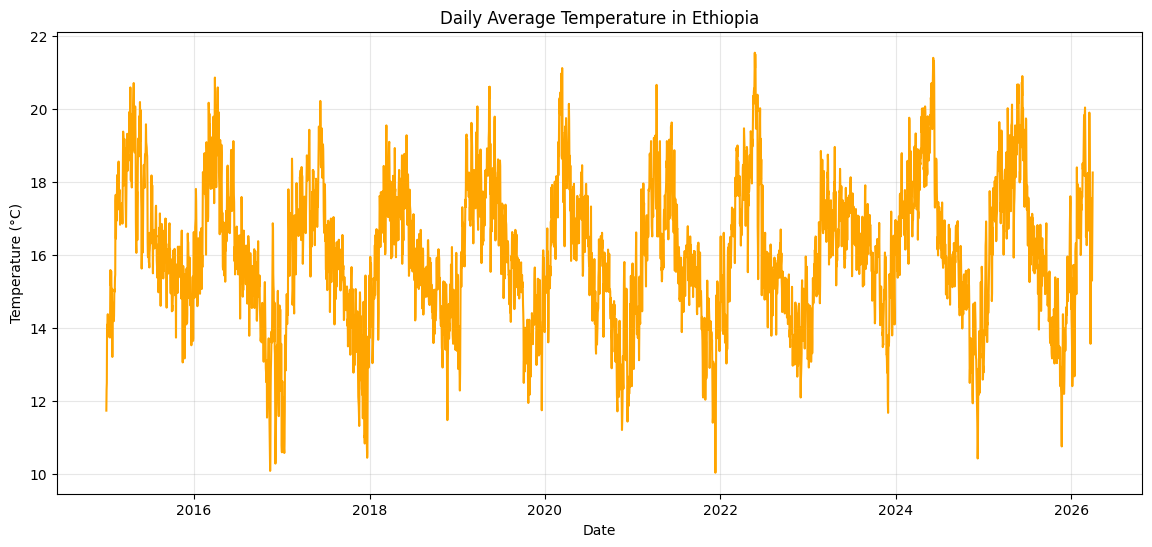

In [7]:
plt.figure(figsize=(14, 6))
sns.lineplot(data=df, x=df.index, y='T2M', color='orange')
plt.title('Daily Average Temperature in Ethiopia')
plt.ylabel('Temperature (°C)')
plt.grid(True, alpha=0.3)
plt.show()

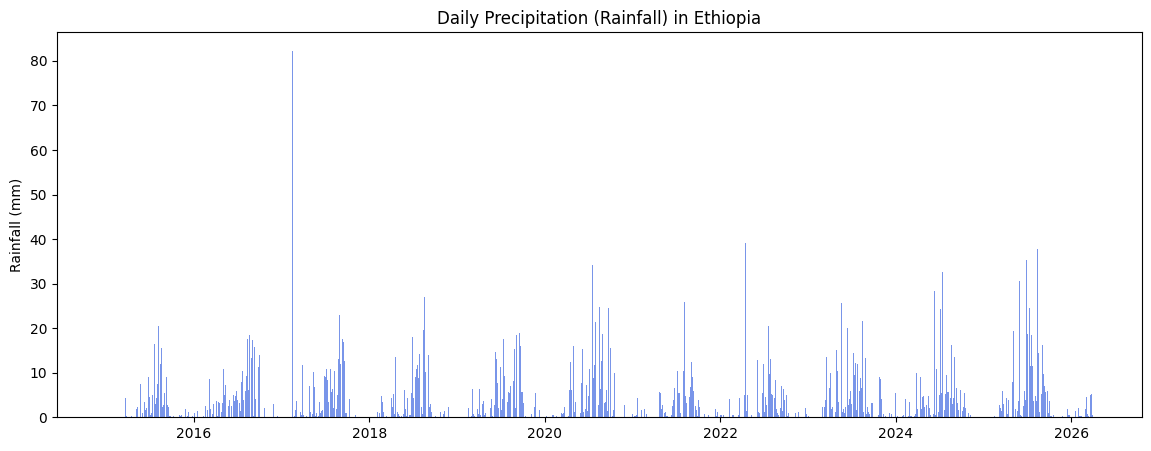

In [8]:
plt.figure(figsize=(14, 5))
plt.bar(df.index, df['PRECTOTCORR'], color='royalblue', alpha=0.7)
plt.title('Daily Precipitation (Rainfall) in Ethiopia')
plt.ylabel('Rainfall (mm)')
plt.show()

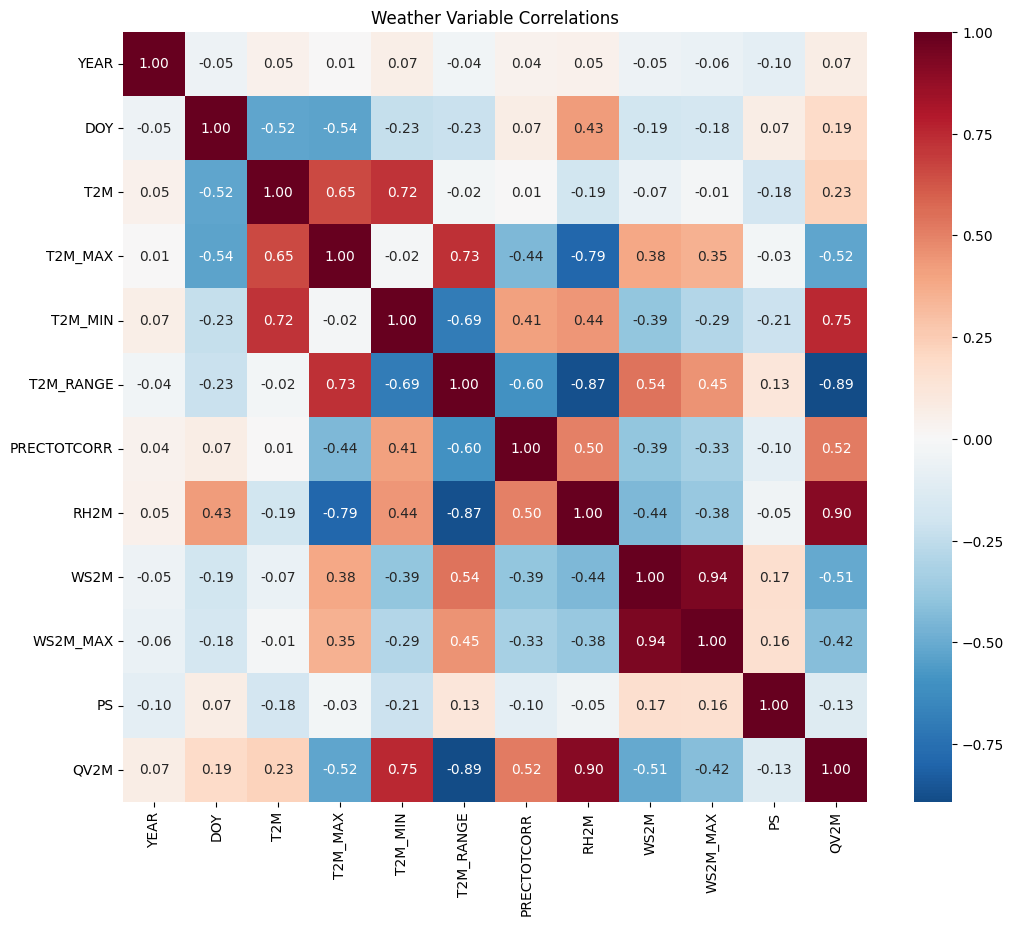

In [9]:
plt.figure(figsize=(12, 10))
# We calculate the correlation matrix
correlation_matrix = df.corr()

# Plot the heatmap
sns.heatmap(correlation_matrix, annot=True, cmap='RdBu_r', center=0, fmt=".2f")
plt.title('Weather Variable Correlations')
plt.show()

In [10]:
import numpy as np
from scipy import stats

# 1. Load and add Country column
df = pd.read_csv('../data/ethiopia.csv')
df['Country'] = 'Ethiopia'

# 2. Convert YEAR/DOY to Date and extract Month
df['Date'] = pd.to_datetime(df['YEAR'] * 1000 + df['DOY'], format='%Y%j')
df['Month'] = df['Date'].dt.month
df.set_index('Date', inplace=True)

# 3. Handle NASA Sentinel values (-999)
df.replace(-999, np.nan, inplace=True)

# 4. Check for duplicates
duplicates = df.duplicated().sum()
print(f"Duplicates found: {duplicates}")
df.drop_duplicates(inplace=True)

# 5. Missing value report
missing_pct = (df.isna().sum() / len(df)) * 100
print("\nMissing Values Percentage:")
print(missing_pct)

Duplicates found: 0

Missing Values Percentage:
YEAR           0.0
DOY            0.0
T2M            0.0
T2M_MAX        0.0
T2M_MIN        0.0
T2M_RANGE      0.0
PRECTOTCORR    0.0
RH2M           0.0
WS2M           0.0
WS2M_MAX       0.0
PS             0.0
QV2M           0.0
Country        0.0
Month          0.0
dtype: float64


In [11]:
cols_to_check = ['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX']
z_scores = np.abs(stats.zscore(df[cols_to_check].dropna()))

# Flagging rows where Z > 3
outliers = (z_scores > 3).all(axis=1)
print(f"Number of outlier rows flagged: {outliers.sum()}")

# Decision: We will retain them for now as weather extremes (like the 80mm rain) 
# are important for climate study, but we acknowledge them.

Number of outlier rows flagged: 0


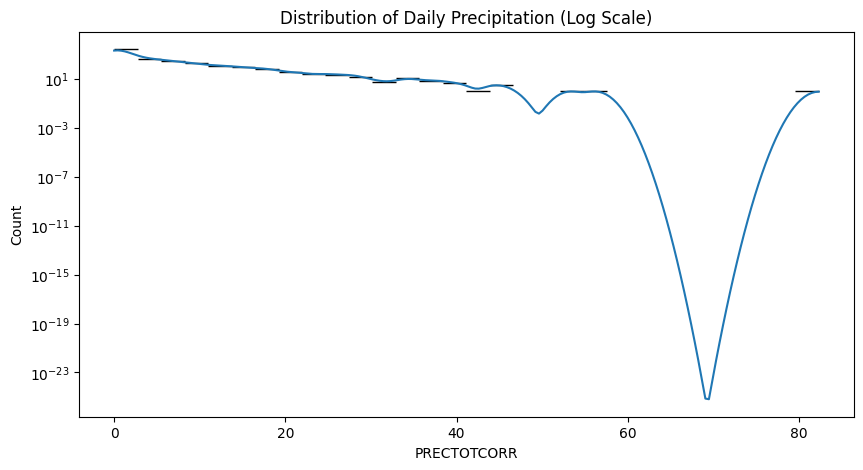

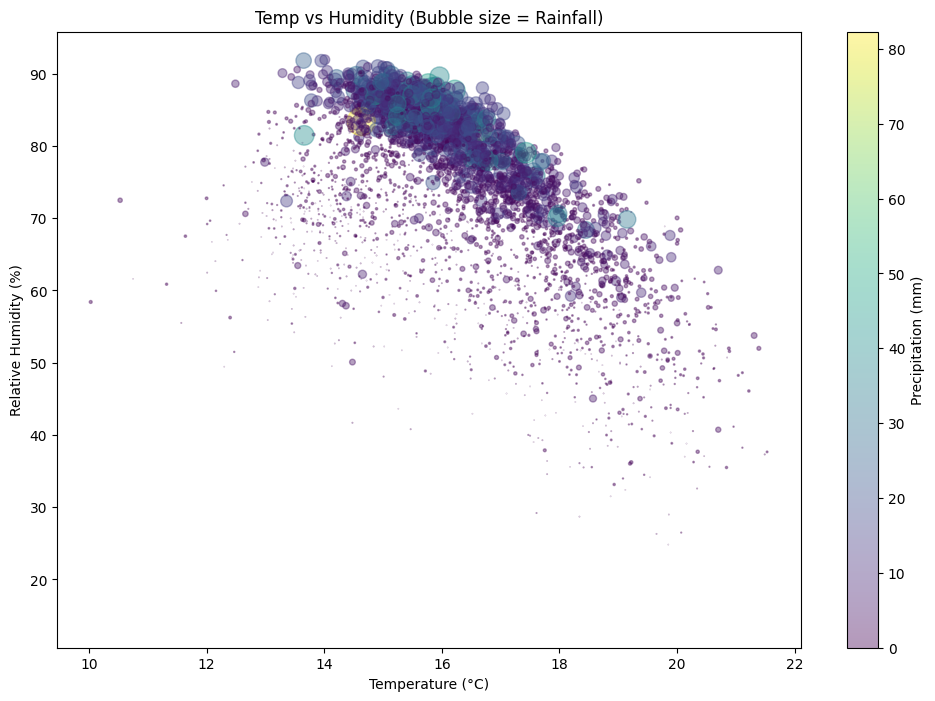

In [12]:
# Histogram of Rainfall (Log scale)
plt.figure(figsize=(10, 5))
sns.histplot(df['PRECTOTCORR'], bins=30, kde=True, log_scale=(False, True))
plt.title('Distribution of Daily Precipitation (Log Scale)')
plt.show()

# Bubble Chart: Temp vs Humidity (Size = Rain)
plt.figure(figsize=(12, 8))
plt.scatter(df['T2M'], df['RH2M'], s=df['PRECTOTCORR']*5, alpha=0.4, c=df['PRECTOTCORR'], cmap='viridis')
plt.colorbar(label='Precipitation (mm)')
plt.xlabel('Temperature (°C)')
plt.ylabel('Relative Humidity (%)')
plt.title('Temp vs Humidity (Bubble size = Rainfall)')
plt.show()

In [13]:
# Create the directory if it doesn't exist
os.makedirs('../data', exist_ok=True)

# Export
df.to_csv('../data/ethiopia_clean.csv')
print("Cleaned data exported to data/ethiopia_clean.csv")

Cleaned data exported to data/ethiopia_clean.csv


Final Analysis: 
Ethiopia Climate TrendsThe Trend: 
Temperatures in Ethiopia remain strictly seasonal and stable over the 10-year period. The line plot shows a recurring "wave" pattern where temperatures consistently peak around 21°C and dip to 10°C annually, with no drastic long-term upward shift visible in this specific window.The Connection: Based on the Heatmap and Bubble Chart, Relative Humidity (RH2M) is the primary driver of rainfall. There is a strong positive correlation ($0.50$) between Humidity and Precipitation; the Bubble Chart visually confirms this, as the largest bubbles (heaviest rain) are clustered at the highest humidity levels (above 80%).The Outliers: While the Z-score check flagged 0 rows for simultaneous extremes across all variables, the Precipitation bar chart shows a significant extreme event in early 2017 (exceeding 80mm). These high-value rain events are retained because they represent critical flash flood risks, which are essential for COP32 infrastructure planning.